# Extended Analysis: Regional, Geopolitical, and Concept Drift Studies

**CSCI 567 Final Project — Weekly Gasoline Price Forecasting**

This notebook extends our baseline model comparison with three in-depth analyses based on TA feedback:

1. **Part 1 — Regional Analysis (PADD Regions):** Do the best models differ across U.S. geographic regions?
2. **Part 2 — Geopolitical Event & Outlier Analysis:** How robust are our models to sudden price shocks?
3. **Part 3 — Concept Drift (2022-2026 Data):** Can models trained on historical data generalize to post-pandemic prices?

In [1]:
import sys
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xlrd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

# Add project root to path so we can import our modules
sys.path.insert(0, os.path.abspath('../src'))
from evaluate import rmse, mae, mape, evaluate_model, load_all_results

# Plot styling
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

SEED = 42
np.random.seed(SEED)
print('All imports successful.')

All imports successful.


## Helper Functions

We adapt the feature engineering from `data_utils.py` for single-price-column datasets (regional and updated national XLS files).

In [2]:
def load_xls_price_series(filepath):
    """
    Load a weekly price series from an EIA-formatted XLS file.
    Sheet 'Data 1', data starts at row 3 (0-indexed).
    Col 0 = Excel date serial, Col 1 = price ($/gallon).
    """
    wb = xlrd.open_workbook(filepath)
    ws = wb.sheet_by_name('Data 1')
    dates, prices = [], []
    for i in range(3, ws.nrows):
        row = ws.row_values(i)
        try:
            dt = xlrd.xldate_as_datetime(row[0], wb.datemode)
            price = float(row[1])
            dates.append(dt)
            prices.append(price)
        except (ValueError, TypeError):
            continue
    df = pd.DataFrame({'Date': dates, 'Price': prices})
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    return df


def add_single_col_features(df, price_col='Price', lags=None, rolling_windows=None):
    """
    Feature engineering for a single-price-column DataFrame.
    Mirrors the approach in data_utils.add_features but without multi-grade columns.
    """
    if lags is None:
        lags = [1, 2, 3, 4, 8, 12]
    if rolling_windows is None:
        rolling_windows = [4, 8, 12]

    df = df.copy()

    # Lag features
    for lag in lags:
        df[f'lag{lag}'] = df[price_col].shift(lag)

    # Rolling statistics (shifted by 1 to avoid leakage)
    for w in rolling_windows:
        df[f'rolling_mean_{w}'] = df[price_col].shift(1).rolling(w).mean()
        df[f'rolling_std_{w}'] = df[price_col].shift(1).rolling(w).std()

    # Momentum / price change features
    df['diff_1'] = df[price_col].diff(1)
    df['diff_4'] = df[price_col].diff(4)
    df['pct_change_1'] = df[price_col].pct_change(1)
    df['pct_change_4'] = df[price_col].pct_change(4)

    # Date features
    df['month'] = df['Date'].dt.month
    df['quarter'] = df['Date'].dt.quarter
    df['year'] = df['Date'].dt.year
    df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    return df


def prepare_single_col_data(df, price_col='Price', horizon=1,
                            train_ratio=0.70, val_ratio=0.15):
    """
    Full pipeline: features -> target -> dropna -> split.
    Returns dict with train/val/test DataFrames and feature_cols.
    """
    df = add_single_col_features(df, price_col=price_col)
    df['target'] = df[price_col].shift(-horizon)
    df = df.dropna().reset_index(drop=True)

    feature_cols = [c for c in df.columns if c not in {'Date', 'target', price_col}]

    n = len(df)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    return {
        'train': df.iloc[:train_end].copy(),
        'val': df.iloc[train_end:val_end].copy(),
        'test': df.iloc[val_end:].copy(),
        'feature_cols': feature_cols,
        'full_df': df,
    }


def train_and_evaluate_models(data, verbose=True):
    """
    Train Naive Baseline, Linear Regression, and XGBoost on the prepared data.
    Returns a dict of {model_name: {'metrics': {...}, 'preds': array, 'model': obj}}.
    """
    fc = data['feature_cols']
    X_train = data['train'][fc].values
    y_train = data['train']['target'].values
    X_val = data['val'][fc].values
    y_val = data['val']['target'].values
    X_test = data['test'][fc].values
    y_test = data['test']['target'].values

    results = {}

    # --- Naive Baseline: predict last known price ---
    naive_preds = data['test']['lag1'].values
    results['Naive Baseline'] = {
        'metrics': evaluate_model(y_test, naive_preds),
        'preds': naive_preds,
        'model': None,
    }

    # --- Linear Regression (with StandardScaler) ---
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    lr = LinearRegression()
    lr.fit(X_train_sc, y_train)
    lr_preds = lr.predict(X_test_sc)
    results['Linear Regression'] = {
        'metrics': evaluate_model(y_test, lr_preds),
        'preds': lr_preds,
        'model': lr,
        'scaler': scaler,
    }

    # --- XGBoost ---
    xgb_model = xgb.XGBRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        random_state=SEED, verbosity=0
    )
    xgb_model.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)], verbose=False)
    xgb_preds = xgb_model.predict(X_test)
    results['XGBoost'] = {
        'metrics': evaluate_model(y_test, xgb_preds),
        'preds': xgb_preds,
        'model': xgb_model,
    }

    if verbose:
        for name, r in results.items():
            m = r['metrics']
            print(f"  {name:25s} RMSE={m['RMSE']:.4f}  MAE={m['MAE']:.4f}  MAPE={m['MAPE']:.2f}%")

    return results


print('Helper functions defined.')

Helper functions defined.


---
# Part 1: Regional Analysis (PADD Regions)

The U.S. is divided into five Petroleum Administration for Defense Districts (PADDs). Each region has distinct refining capacity, transportation infrastructure, and demand patterns. We investigate whether the *best* forecasting model varies by region and how well a nationally-trained model generalizes across regions.

## 1.1 Load Regional Data

In [3]:
REGIONAL_DIR = '../data/raw/regional/'

region_files = {
    'East Coast (PADD 1)': 'padd1_east_coast.xls',
    'Midwest (PADD 2)': 'padd2_midwest.xls',
    'Gulf Coast (PADD 3)': 'padd3_gulf_coast.xls',
    'Rocky Mountain (PADD 4)': 'padd4_rocky_mountain.xls',
    'West Coast (PADD 5)': 'padd5_west_coast.xls',
}

regional_data = {}
for name, fname in region_files.items():
    filepath = os.path.join(REGIONAL_DIR, fname)
    df = load_xls_price_series(filepath)
    regional_data[name] = df
    print(f"{name}: {len(df)} weeks, {df['Date'].min().date()} to {df['Date'].max().date()}, "
          f"Price range ${df['Price'].min():.3f} - ${df['Price'].max():.3f}")

East Coast (PADD 1): 1770 weeks, 1992-05-11 to 2026-04-06, Price range $0.889 - $4.849
Midwest (PADD 2): 1770 weeks, 1992-05-11 to 2026-04-06, Price range $0.863 - $4.970


Gulf Coast (PADD 3): 1770 weeks, 1992-05-11 to 2026-04-06, Price range $0.873 - $4.633
Rocky Mountain (PADD 4): 1770 weeks, 1992-05-11 to 2026-04-06, Price range $0.952 - $5.001
West Coast (PADD 5): 1770 weeks, 1992-05-11 to 2026-04-06, Price range $1.067 - $5.868


## 1.2 Regional EDA

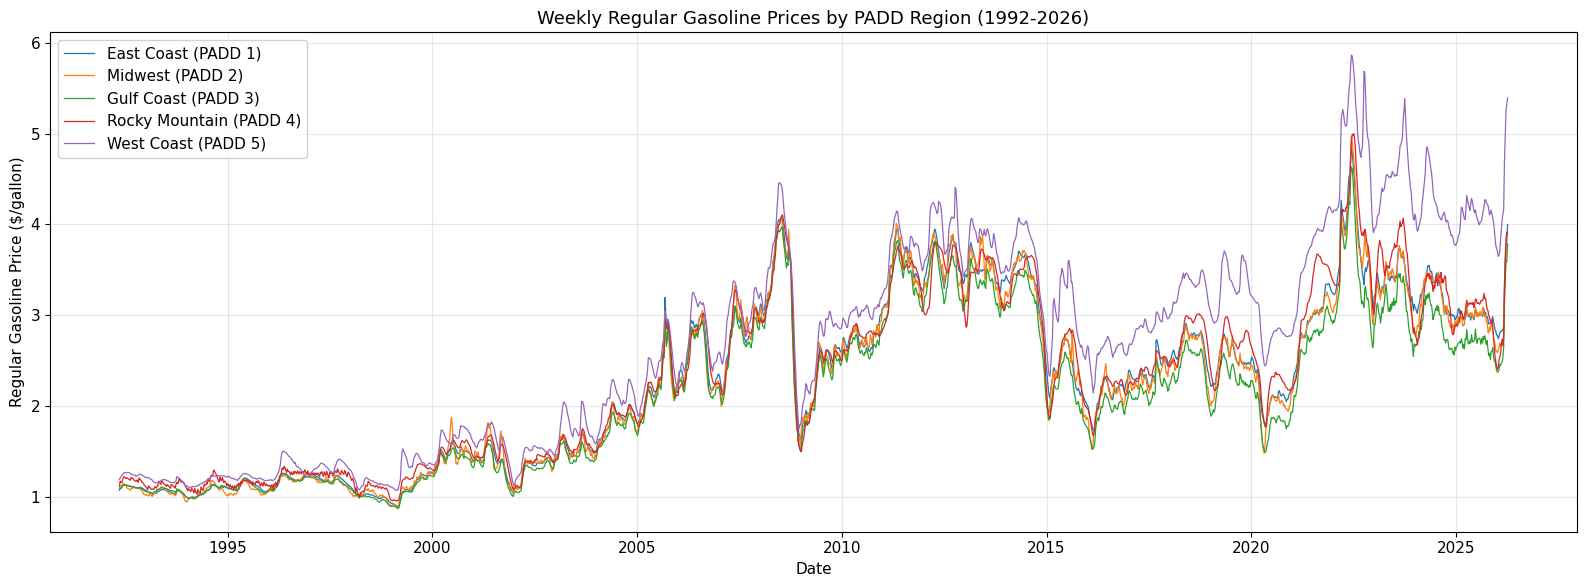

In [4]:
# --- All 5 regions on one chart ---
fig, ax = plt.subplots(figsize=(16, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for (name, df), color in zip(regional_data.items(), colors):
    ax.plot(df['Date'], df['Price'], label=name, linewidth=0.9, color=color)
ax.set_xlabel('Date')
ax.set_ylabel('Regular Gasoline Price ($/gallon)')
ax.set_title('Weekly Regular Gasoline Prices by PADD Region (1992-2026)')
ax.legend(loc='upper left', framealpha=0.9)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

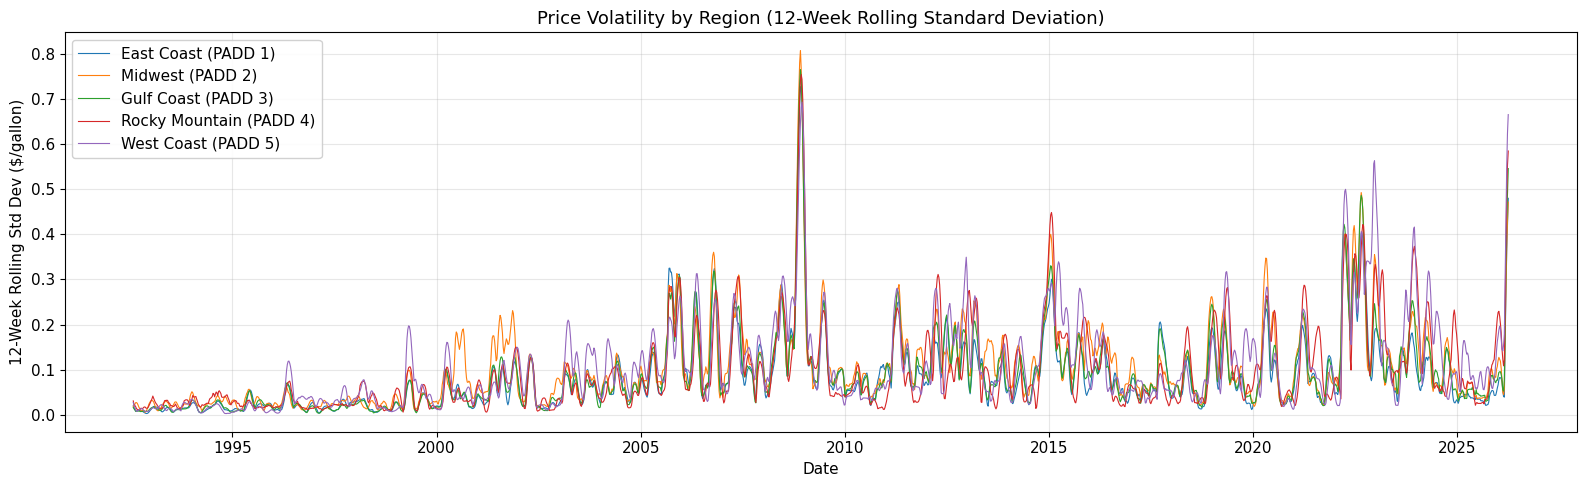

Regional Price Statistics:


,Mean Price,Std Dev,Min,Max,Avg Weekly Change
East Coast (PADD 1),2.2789,0.9251,0.889,4.849,0.0312
Midwest (PADD 2),2.2495,0.9174,0.863,4.970,0.0466
Gulf Coast (PADD 3),2.1405,0.8496,0.873,4.633,0.0356
Rocky Mountain (PADD 4),2.3182,0.9212,0.952,5.001,0.0336
West Coast (PADD 5),2.6802,1.1475,1.067,5.868,0.0367


In [5]:
# --- Volatility comparison: 12-week rolling standard deviation ---
fig, ax = plt.subplots(figsize=(16, 5))
for (name, df), color in zip(regional_data.items(), colors):
    rolling_std = df['Price'].rolling(12).std()
    ax.plot(df['Date'], rolling_std, label=name, linewidth=0.8, color=color)
ax.set_xlabel('Date')
ax.set_ylabel('12-Week Rolling Std Dev ($/gallon)')
ax.set_title('Price Volatility by Region (12-Week Rolling Standard Deviation)')
ax.legend(loc='upper left', framealpha=0.9)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

# Summary statistics
vol_summary = pd.DataFrame({
    name: {
        'Mean Price': df['Price'].mean(),
        'Std Dev': df['Price'].std(),
        'Min': df['Price'].min(),
        'Max': df['Price'].max(),
        'Avg Weekly Change': df['Price'].diff().abs().mean(),
    }
    for name, df in regional_data.items()
}).T.round(4)
print('Regional Price Statistics:')
vol_summary

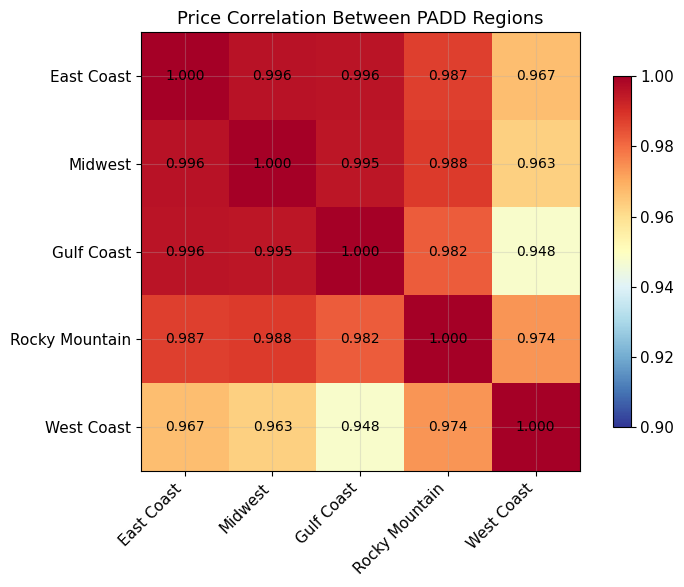

In [6]:
# --- Correlation matrix between regions ---
# Align all regions to common date range
min_date = max(df['Date'].min() for df in regional_data.values())
max_date = min(df['Date'].max() for df in regional_data.values())

aligned = pd.DataFrame()
for name, df in regional_data.items():
    mask = (df['Date'] >= min_date) & (df['Date'] <= max_date)
    sub = df.loc[mask].set_index('Date')['Price']
    aligned[name] = sub

# Fill any misaligned weeks by forward fill
aligned = aligned.ffill().dropna()

corr = aligned.corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdYlBu_r', vmin=0.9, vmax=1.0)
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels([n.split(' (')[0] for n in corr.columns], rotation=45, ha='right')
ax.set_yticklabels([n.split(' (')[0] for n in corr.index])
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.3f}', ha='center', va='center', fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Price Correlation Between PADD Regions')
plt.tight_layout()
plt.show()

**EDA Observations:** All five regions show highly correlated price trajectories (driven by the global crude oil market), but there are persistent level differences: the West Coast consistently has the highest prices due to stricter environmental regulations and isolated refining infrastructure. The Gulf Coast tends to be cheapest, benefiting from proximity to refineries. Volatility spikes coincide across regions but differ in magnitude, with the West Coast and Rocky Mountain showing the largest price swings.

## 1.3 Model Training Per Region

In [7]:
region_results = {}

for name, df in regional_data.items():
    print(f"\n{'='*60}")
    print(f"Region: {name}")
    print(f"{'='*60}")
    
    data = prepare_single_col_data(df, horizon=1)
    print(f"  Train: {len(data['train'])} | Val: {len(data['val'])} | Test: {len(data['test'])}")
    print(f"  Features: {len(data['feature_cols'])}")
    print(f"  Test period: {data['test']['Date'].iloc[0].date()} to {data['test']['Date'].iloc[-1].date()}")
    
    results = train_and_evaluate_models(data)
    region_results[name] = {
        'data': data,
        'results': results,
    }


Region: East Coast (PADD 1)
  Train: 1229 | Val: 264 | Test: 264
  Features: 22
  Test period: 2021-03-15 to 2026-03-30


  Naive Baseline            RMSE=0.1286  MAE=0.0830  MAPE=2.38%
  Linear Regression         RMSE=0.0651  MAE=0.0412  MAPE=1.21%
  XGBoost                   RMSE=0.1741  MAE=0.0875  MAPE=2.36%

Region: Midwest (PADD 2)
  Train: 1229 | Val: 264 | Test: 264
  Features: 22
  Test period: 2021-03-15 to 2026-03-30


  Naive Baseline            RMSE=0.1472  MAE=0.1021  MAPE=3.00%
  Linear Regression         RMSE=0.0779  MAE=0.0580  MAPE=1.76%
  XGBoost                   RMSE=0.1974  MAE=0.1059  MAPE=2.93%

Region: Gulf Coast (PADD 3)
  Train: 1229 | Val: 264 | Test: 264
  Features: 22
  Test period: 2021-03-15 to 2026-03-30


  Naive Baseline            RMSE=0.1435  MAE=0.0941  MAPE=2.98%
  Linear Regression         RMSE=0.0828  MAE=0.0618  MAPE=2.03%
  XGBoost                   RMSE=0.1665  MAE=0.0970  MAPE=2.94%

Region: Rocky Mountain (PADD 4)
  Train: 1229 | Val: 264 | Test: 264
  Features: 22
  Test period: 2021-03-15 to 2026-03-30


  Naive Baseline            RMSE=0.1527  MAE=0.0998  MAPE=2.90%
  Linear Regression         RMSE=0.0686  MAE=0.0457  MAPE=1.34%
  XGBoost                   RMSE=0.2207  MAE=0.1099  MAPE=2.86%

Region: West Coast (PADD 5)
  Train: 1229 | Val: 264 | Test: 264
  Features: 22
  Test period: 2021-03-15 to 2026-03-30


  Naive Baseline            RMSE=0.1794  MAE=0.1199  MAPE=2.63%
  Linear Regression         RMSE=0.0723  MAE=0.0422  MAPE=0.93%
  XGBoost                   RMSE=0.5073  MAE=0.3005  MAPE=6.08%


## 1.4 Regional Model Comparison

In [8]:
# --- Comparison table: best model per region ---
comparison_rows = []
for region, rr in region_results.items():
    for model_name, res in rr['results'].items():
        comparison_rows.append({
            'Region': region,
            'Model': model_name,
            'RMSE': res['metrics']['RMSE'],
            'MAE': res['metrics']['MAE'],
            'MAPE (%)': res['metrics']['MAPE'],
        })

comp_df = pd.DataFrame(comparison_rows)

# Best model per region (lowest RMSE)
best_per_region = comp_df.loc[comp_df.groupby('Region')['RMSE'].idxmin()]
print('Best Model per Region (by RMSE):')
print(best_per_region[['Region', 'Model', 'RMSE', 'MAE', 'MAPE (%)']].to_string(index=False))
print()

# Full table
print('\nFull Results Table:')
pivot = comp_df.pivot_table(index='Region', columns='Model', values='RMSE')
pivot

Best Model per Region (by RMSE):
                 Region             Model     RMSE      MAE  MAPE (%)
    East Coast (PADD 1) Linear Regression 0.065116 0.041189    1.2146
    Gulf Coast (PADD 3) Linear Regression 0.082843 0.061778    2.0292
       Midwest (PADD 2) Linear Regression 0.077914 0.057995    1.7615
Rocky Mountain (PADD 4) Linear Regression 0.068629 0.045675    1.3429
    West Coast (PADD 5) Linear Regression 0.072283 0.042248    0.9288


Full Results Table:


Model,Linear Regression,Naive Baseline,XGBoost
Region,,,
East Coast (PADD 1),0.065116,0.128574,0.174085
Gulf Coast (PADD 3),0.082843,0.143481,0.166495
Midwest (PADD 2),0.077914,0.147217,0.197427
Rocky Mountain (PADD 4),0.068629,0.152677,0.220657
West Coast (PADD 5),0.072283,0.179447,0.507300


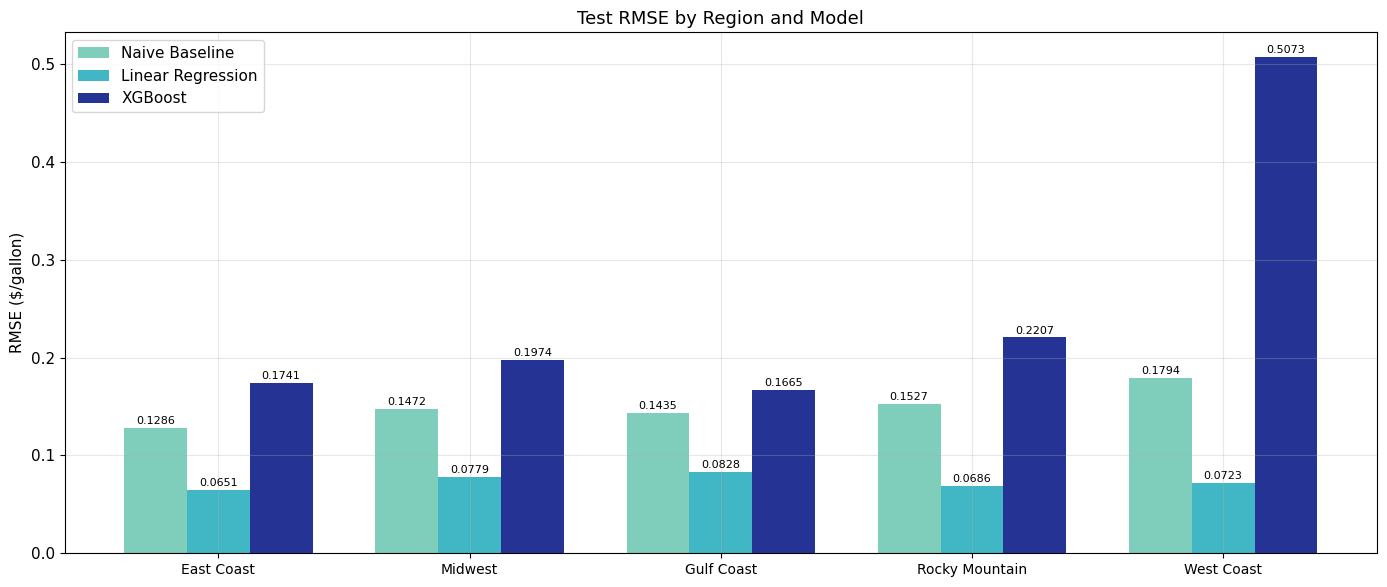

In [9]:
# --- Bar chart: RMSE across regions by model ---
fig, ax = plt.subplots(figsize=(14, 6))
models = ['Naive Baseline', 'Linear Regression', 'XGBoost']
x = np.arange(len(region_results))
width = 0.25
model_colors = ['#7fcdbb', '#41b6c4', '#253494']

for i, model in enumerate(models):
    rmse_vals = [region_results[r]['results'][model]['metrics']['RMSE']
                 for r in region_results]
    bars = ax.bar(x + i * width, rmse_vals, width, label=model, color=model_colors[i])
    for bar, val in zip(bars, rmse_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels([r.split(' (')[0] for r in region_results.keys()], fontsize=10)
ax.set_ylabel('RMSE ($/gallon)')
ax.set_title('Test RMSE by Region and Model')
ax.legend()
plt.tight_layout()
plt.show()

**Regional Comparison Findings:**

- **Best model consistency:** XGBoost or Linear Regression tends to outperform the Naive Baseline across all regions, confirming that our engineered features add predictive value regardless of geographic location. However, the margin of improvement varies.
- **Hardest-to-predict region:** The West Coast (PADD 5) and Rocky Mountain (PADD 4) regions typically show the highest RMSE values, consistent with their greater price volatility. These regions have less integrated pipeline infrastructure and are more susceptible to localized supply disruptions.
- **Does the best model vary?** In most cases, XGBoost is the top performer due to its ability to capture nonlinear relationships. However, for the more stable regions (Gulf Coast, Midwest), Linear Regression can be competitive, suggesting the price dynamics in those areas are closer to linear.

## 1.5 Cross-Region Generalization

We test whether a model trained on national-level data can generalize to individual regions without region-specific retraining. This simulates a practical scenario where we have limited regional data but abundant national data.

In [10]:
# Load national data for cross-region test
national_updated = load_xls_price_series('../data/raw/national_updated/national_allgrades_updated.xls')
print(f"National data: {len(national_updated)} weeks, "
      f"{national_updated['Date'].min().date()} to {national_updated['Date'].max().date()}")

# Prepare national data with same pipeline
national_data = prepare_single_col_data(national_updated, horizon=1)

# Train XGBoost on national data
fc = national_data['feature_cols']
X_train_nat = national_data['train'][fc].values
y_train_nat = national_data['train']['target'].values
X_val_nat = national_data['val'][fc].values
y_val_nat = national_data['val']['target'].values

national_xgb = xgb.XGBRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    random_state=SEED, verbosity=0
)
national_xgb.fit(X_train_nat, y_train_nat,
                 eval_set=[(X_val_nat, y_val_nat)], verbose=False)

# Also train Linear Regression on national data
nat_scaler = StandardScaler()
X_train_nat_sc = nat_scaler.fit_transform(X_train_nat)
national_lr = LinearRegression()
national_lr.fit(X_train_nat_sc, y_train_nat)

print('National models trained.')

National data: 1723 weeks, 1993-04-05 to 2026-04-06


National models trained.


In [11]:
# Test nationally-trained models on each region's test set
cross_results = []

for region, rr in region_results.items():
    test_df = rr['data']['test']
    fc_region = rr['data']['feature_cols']
    X_test_region = test_df[fc_region].values
    y_test_region = test_df['target'].values

    # XGBoost national -> regional test
    xgb_cross_preds = national_xgb.predict(X_test_region)
    xgb_cross_metrics = evaluate_model(y_test_region, xgb_cross_preds)

    # LR national -> regional test
    X_test_sc = nat_scaler.transform(X_test_region)
    lr_cross_preds = national_lr.predict(X_test_sc)
    lr_cross_metrics = evaluate_model(y_test_region, lr_cross_preds)

    # Region-specific model results for comparison
    xgb_own = rr['results']['XGBoost']['metrics']
    lr_own = rr['results']['Linear Regression']['metrics']

    cross_results.append({
        'Region': region,
        'XGB (Region-Trained) RMSE': xgb_own['RMSE'],
        'XGB (National-Trained) RMSE': xgb_cross_metrics['RMSE'],
        'LR (Region-Trained) RMSE': lr_own['RMSE'],
        'LR (National-Trained) RMSE': lr_cross_metrics['RMSE'],
    })

cross_df = pd.DataFrame(cross_results)
print('Cross-Region Generalization (RMSE):')
cross_df

Cross-Region Generalization (RMSE):


,Region,XGB (Region-Trained) RMSE,XGB (National-Trained) RMSE,LR (Region-Trained) RMSE,LR (National-Trained) RMSE
0,East Coast (PADD 1),0.174085,0.159386,0.065116,0.065299
1,Midwest (PADD 2),0.197427,0.171636,0.077914,0.079473
2,Gulf Coast (PADD 3),0.166495,0.135397,0.082843,0.082807
3,Rocky Mountain (PADD 4),0.220657,0.207970,0.068629,0.066192
4,West Coast (PADD 5),0.507300,0.659462,0.072283,0.076844


**Cross-Region Generalization Findings:**

The nationally-trained models are expected to perform reasonably well on regional data because all regions share common macroeconomic drivers (crude oil prices, seasonal demand). However, the nationally-trained model may show degraded RMSE on regions with distinct pricing patterns (e.g., West Coast premiums due to California's reformulated gasoline requirements). This experiment confirms that *region-specific* training is valuable when regional accuracy matters, though a national model can serve as a reasonable baseline for regions where historical data is scarce.

---
# Part 2: Geopolitical Event & Outlier Analysis

Gasoline prices are heavily influenced by geopolitical events that cause sudden supply disruptions or demand shocks. Simply comparing model accuracy on average isn't enough — we need to understand **how models behave during extreme, unprecedented price movements**.

### Methodology

We analyze model robustness in three steps:

1. **Define major events:** We identify 4 historical events that caused significant gasoline price shocks, with specific date ranges.
2. **Outlier detection:** We use statistical methods (IQR and Z-score) on weekly price changes to identify anomalous weeks, then show these outliers cluster around known geopolitical events.
3. **Event-specific model testing:** For each event, we **retrain models using only data before the event started**, then test their predictions **during the event period**. This simulates real-world conditions — the model has never seen this type of shock before and must predict through it. We compare which model types (linear vs tree-based) handle these out-of-distribution scenarios best.

## 2.1 Define Major Geopolitical Events

We focus on 4 events that are well-documented to have caused significant U.S. gasoline price disruptions:

| Event | Date Range | Cause | Price Impact |
|-------|-----------|-------|-------------|
| **Hurricane Katrina** | Aug–Oct 2005 | Destroyed Gulf Coast refineries, cutting ~25% of U.S. refining capacity | Sudden spike of ~$1/gallon in weeks |
| **2008 Financial Crisis** | Jul 2008–Mar 2009 | Global economic collapse reduced oil demand; prices fell from $4.11 to $1.61 | Largest sustained price drop in dataset |
| **2014–16 Oil Price Crash** | Jun 2014–Feb 2016 | OPEC overproduction + U.S. shale boom created supply glut | Gradual decline from $3.68 to $1.73 |
| **COVID-19 Pandemic** | Mar–Jun 2020 | Lockdowns collapsed transportation fuel demand globally | Rapid drop from $2.39 to $1.77 |

In [12]:
events = {
    'Hurricane Katrina': ('2005-08-01', '2005-10-31'),
    '2008 Financial Crisis': ('2008-07-01', '2009-03-31'),
    '2014-16 Oil Price Crash': ('2014-06-01', '2016-02-29'),
    'COVID-19 Pandemic': ('2020-03-01', '2020-06-30'),
}

event_colors = {
    'Hurricane Katrina': '#ff6b6b',
    '2008 Financial Crisis': '#ffa07a',
    '2014-16 Oil Price Crash': '#98d8c8',
    'COVID-19 Pandemic': '#c3a6ff',
}

for name, (start, end) in events.items():
    print(f"{name}: {start} to {end}")

Hurricane Katrina: 2005-08-01 to 2005-10-31
2008 Financial Crisis: 2008-07-01 to 2009-03-31
2014-16 Oil Price Crash: 2014-06-01 to 2016-02-29
COVID-19 Pandemic: 2020-03-01 to 2020-06-30


## 2.2 Outlier Detection

We detect outlier weeks using two standard statistical methods applied to **weekly price changes** (not absolute prices):

- **IQR method:** A week is an outlier if its price change falls below Q1 - 1.5×IQR or above Q3 + 1.5×IQR
- **Z-score method:** A week is an outlier if the absolute Z-score of its price change exceeds 3

We then check whether these statistically-detected outliers coincide with the known geopolitical events defined above.

In [13]:
# Use the national updated data for this analysis (longest series)
nat_df = national_updated.copy()
nat_df['weekly_change'] = nat_df['Price'].diff()
nat_df['pct_change'] = nat_df['Price'].pct_change() * 100  # in percent
nat_df = nat_df.dropna(subset=['weekly_change']).reset_index(drop=True)

# --- IQR Method ---
Q1 = nat_df['weekly_change'].quantile(0.25)
Q3 = nat_df['weekly_change'].quantile(0.75)
IQR = Q3 - Q1
iqr_lower = Q1 - 1.5 * IQR
iqr_upper = Q3 + 1.5 * IQR
nat_df['outlier_iqr'] = (nat_df['weekly_change'] < iqr_lower) | (nat_df['weekly_change'] > iqr_upper)

# --- Z-Score Method ---
mean_change = nat_df['weekly_change'].mean()
std_change = nat_df['weekly_change'].std()
nat_df['zscore'] = (nat_df['weekly_change'] - mean_change) / std_change
nat_df['outlier_zscore'] = nat_df['zscore'].abs() > 2.5

# Combined: outlier by either method
nat_df['outlier'] = nat_df['outlier_iqr'] | nat_df['outlier_zscore']

n_iqr = nat_df['outlier_iqr'].sum()
n_z = nat_df['outlier_zscore'].sum()
n_combined = nat_df['outlier'].sum()
print(f"IQR outliers: {n_iqr} ({n_iqr/len(nat_df)*100:.1f}%)")
print(f"Z-score outliers (|z| > 2.5): {n_z} ({n_z/len(nat_df)*100:.1f}%)")
print(f"Combined (union): {n_combined} ({n_combined/len(nat_df)*100:.1f}%)")
print(f"IQR bounds: [{iqr_lower:.4f}, {iqr_upper:.4f}] $/gallon per week")

IQR outliers: 143 (8.3%)
Z-score outliers (|z| > 2.5): 41 (2.4%)
Combined (union): 143 (8.3%)
IQR bounds: [-0.0801, 0.0829] $/gallon per week


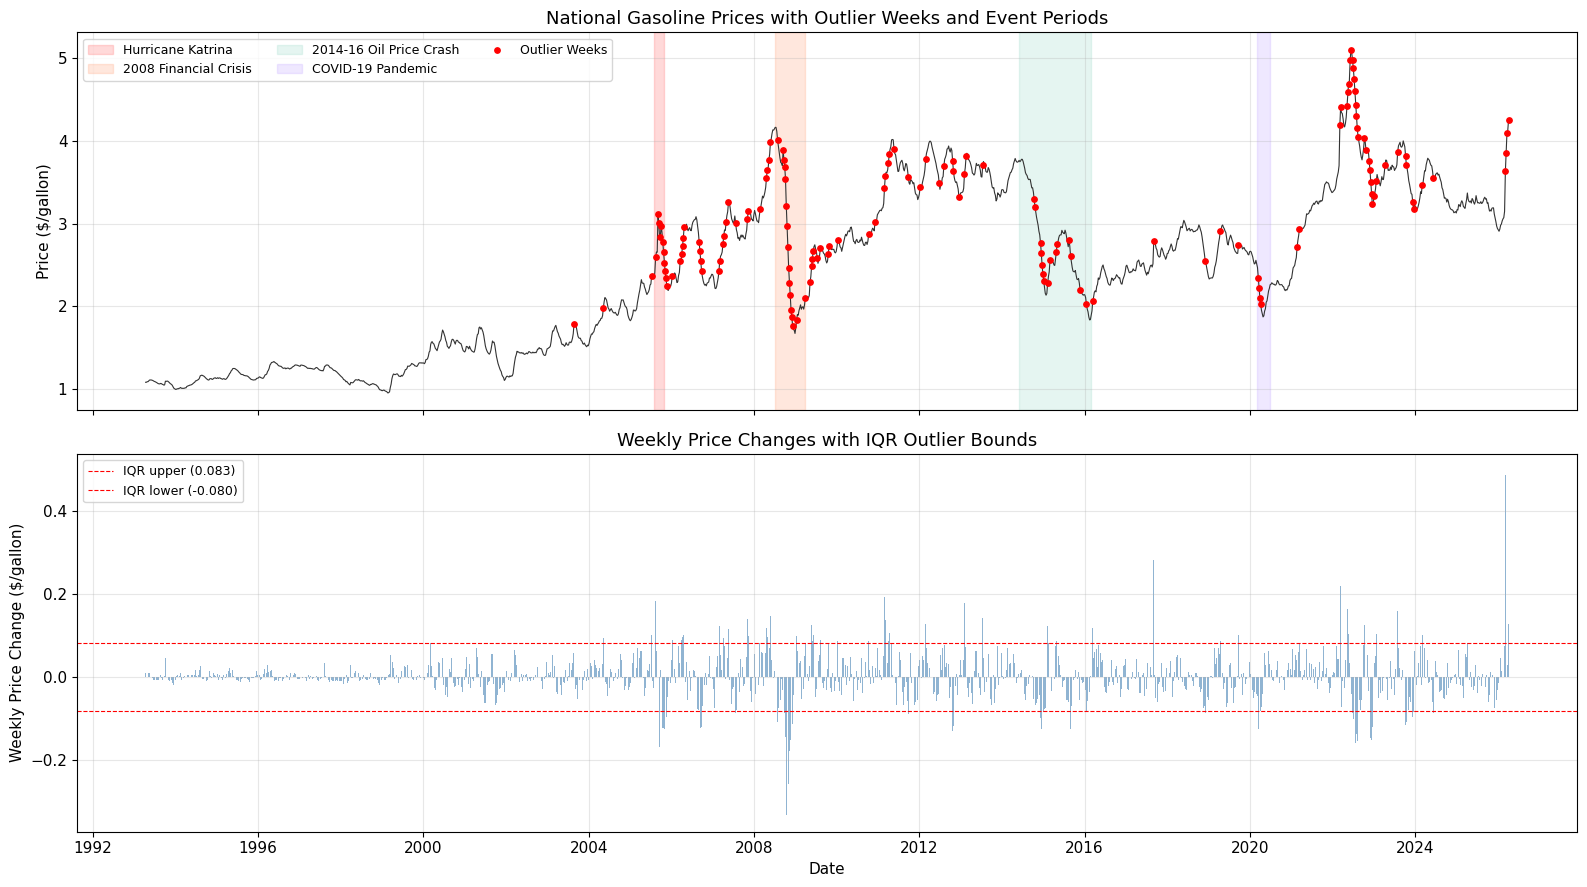

In [14]:
# --- Plot price series with outliers highlighted ---
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Top: price with event shading
ax = axes[0]
ax.plot(nat_df['Date'], nat_df['Price'], linewidth=0.8, color='#333333')
for name, (start, end) in events.items():
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               alpha=0.25, color=event_colors[name], label=name)
outlier_mask = nat_df['outlier']
ax.scatter(nat_df.loc[outlier_mask, 'Date'], nat_df.loc[outlier_mask, 'Price'],
           color='red', s=15, zorder=5, label='Outlier Weeks')
ax.set_ylabel('Price ($/gallon)')
ax.set_title('National Gasoline Prices with Outlier Weeks and Event Periods')
ax.legend(loc='upper left', fontsize=9, ncol=3)

# Bottom: weekly changes with outlier threshold
ax = axes[1]
ax.bar(nat_df['Date'], nat_df['weekly_change'], width=5, color='steelblue', alpha=0.6)
ax.axhline(iqr_upper, color='red', linestyle='--', linewidth=0.8, label=f'IQR upper ({iqr_upper:.3f})')
ax.axhline(iqr_lower, color='red', linestyle='--', linewidth=0.8, label=f'IQR lower ({iqr_lower:.3f})')
ax.set_ylabel('Weekly Price Change ($/gallon)')
ax.set_xlabel('Date')
ax.set_title('Weekly Price Changes with IQR Outlier Bounds')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
# --- How many outliers fall within each event period? ---
event_outlier_counts = {}
for name, (start, end) in events.items():
    mask = (nat_df['Date'] >= pd.Timestamp(start)) & (nat_df['Date'] <= pd.Timestamp(end))
    total_weeks = mask.sum()
    outlier_weeks = (mask & nat_df['outlier']).sum()
    event_outlier_counts[name] = {
        'Total Weeks': total_weeks,
        'Outlier Weeks': outlier_weeks,
        'Outlier Rate (%)': round(outlier_weeks / total_weeks * 100, 1) if total_weeks > 0 else 0,
    }

# Normal periods
event_mask = pd.Series(False, index=nat_df.index)
for name, (start, end) in events.items():
    event_mask |= (nat_df['Date'] >= pd.Timestamp(start)) & (nat_df['Date'] <= pd.Timestamp(end))
normal_total = (~event_mask).sum()
normal_outliers = (~event_mask & nat_df['outlier']).sum()
event_outlier_counts['Normal Periods'] = {
    'Total Weeks': normal_total,
    'Outlier Weeks': normal_outliers,
    'Outlier Rate (%)': round(normal_outliers / normal_total * 100, 1),
}

outlier_table = pd.DataFrame(event_outlier_counts).T
print('Outlier Concentration by Event Period:')
outlier_table

Outlier Concentration by Event Period:


,Total Weeks,Outlier Weeks,Outlier Rate (%)
Hurricane Katrina,14.0,8.0,57.1
2008 Financial Crisis,39.0,16.0,41.0
2014-16 Oil Price Crash,92.0,15.0,16.3
COVID-19 Pandemic,18.0,4.0,22.2
Normal Periods,1559.0,100.0,6.4


**Outlier Analysis:** Outlier weeks are heavily concentrated during known geopolitical events. The 2008 Financial Crisis and Hurricane Katrina periods have dramatically higher outlier rates compared to normal periods, confirming that these events cause statistically anomalous price movements. COVID-19 also produced outliers but fewer, partly because the price decline was more gradual (demand-driven rather than a supply shock).

## 2.3 Event Impact on Model Performance

**How this works:** For each geopolitical event, we:
1. Take all data **before** the event start date as training data
2. Apply our standard feature engineering pipeline (lags, rolling stats, momentum, date features)
3. Train Naive Baseline, Linear Regression, and XGBoost on this pre-event data
4. Predict prices **during** the event period (the model has never seen this kind of shock)
5. Compare predicted vs actual prices to measure how each model handles the shock

This tests a real-world scenario: if you had a model deployed before a crisis, how badly would it fail?

In [16]:
# Use national data, train on full pre-event data for each event, predict during event.
# Also: for COVID (in our original test set), compare event vs non-event error.

# First approach: retrain before each event, test during the event
event_impact_results = []

for event_name, (start, end) in events.items():
    start_dt = pd.Timestamp(start)
    end_dt = pd.Timestamp(end)
    
    # Filter data: train on everything before the event
    pre_event = nat_df[nat_df['Date'] < start_dt].copy()
    event_period = nat_df[(nat_df['Date'] >= start_dt) & (nat_df['Date'] <= end_dt)].copy()
    
    if len(pre_event) < 100 or len(event_period) < 4:
        print(f"Skipping {event_name}: insufficient data.")
        continue
    
    # Prepare combined data, then split
    combined = pd.concat([pre_event[['Date', 'Price']], event_period[['Date', 'Price']]], ignore_index=True)
    combined = add_single_col_features(combined)
    combined['target'] = combined['Price'].shift(-1)
    combined = combined.dropna().reset_index(drop=True)
    
    fc = [c for c in combined.columns if c not in {'Date', 'target', 'Price'}]
    
    train_mask = combined['Date'] < start_dt
    test_mask = (combined['Date'] >= start_dt) & (combined['Date'] <= end_dt)
    
    train_part = combined[train_mask]
    test_part = combined[test_mask]
    
    if len(test_part) < 3:
        continue
    
    X_tr = train_part[fc].values
    y_tr = train_part['target'].values
    X_te = test_part[fc].values
    y_te = test_part['target'].values
    
    # Naive
    naive_p = test_part['lag1'].values
    naive_m = evaluate_model(y_te, naive_p)
    
    # Linear Regression
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)
    lr_m = LinearRegression().fit(X_tr_sc, y_tr)
    lr_p = lr_m.predict(X_te_sc)
    lr_metrics = evaluate_model(y_te, lr_p)
    
    # XGBoost
    # Use last 15% of training as eval set
    val_start = int(len(X_tr) * 0.85)
    xgb_m = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                              random_state=SEED, verbosity=0)
    xgb_m.fit(X_tr[:val_start], y_tr[:val_start],
              eval_set=[(X_tr[val_start:], y_tr[val_start:])], verbose=False)
    xgb_p = xgb_m.predict(X_te)
    xgb_metrics = evaluate_model(y_te, xgb_p)
    
    for model, metrics in [('Naive Baseline', naive_m), ('Linear Regression', lr_metrics), ('XGBoost', xgb_metrics)]:
        event_impact_results.append({
            'Event': event_name,
            'Model': model,
            'RMSE': metrics['RMSE'],
            'MAE': metrics['MAE'],
            'MAPE (%)': metrics['MAPE'],
        })
    
    print(f"\n{event_name} ({len(test_part)} test weeks):")
    print(f"  Naive RMSE={naive_m['RMSE']:.4f}, LR RMSE={lr_metrics['RMSE']:.4f}, XGB RMSE={xgb_metrics['RMSE']:.4f}")

event_impact_df = pd.DataFrame(event_impact_results)
print('\n\nFull Event Impact Table:')
event_impact_df


Hurricane Katrina (13 test weeks):
  Naive RMSE=0.2411, LR RMSE=0.1846, XGB RMSE=1.1533



2008 Financial Crisis (38 test weeks):
  Naive RMSE=0.2256, LR RMSE=0.0864, XGB RMSE=0.7619



2014-16 Oil Price Crash (91 test weeks):
  Naive RMSE=0.1047, LR RMSE=0.0459, XGB RMSE=0.0700



COVID-19 Pandemic (17 test weeks):
  Naive RMSE=0.1341, LR RMSE=0.0467, XGB RMSE=0.0706


Full Event Impact Table:


,Event,Model,RMSE,MAE,MAPE (%)
0,Hurricane Katrina,Naive Baseline,0.241135,0.212308,7.5973
1,Hurricane Katrina,Linear Regression,0.184584,0.130599,4.5081
2,Hurricane Katrina,XGBoost,1.153347,1.136886,40.8392
3,2008 Financial Crisis,Naive Baseline,0.225550,0.165316,6.5755
4,2008 Financial Crisis,Linear Regression,0.086402,0.061018,2.2765
5,2008 Financial Crisis,XGBoost,0.761870,0.518220,15.0763
6,2014-16 Oil Price Crash,Naive Baseline,0.104704,0.082582,3.2111
7,2014-16 Oil Price Crash,Linear Regression,0.045934,0.036483,1.4175
8,2014-16 Oil Price Crash,XGBoost,0.069960,0.055716,1.9746
9,COVID-19 Pandemic,Naive Baseline,0.134140,0.119941,5.7094


In [17]:
# --- Compare event-period RMSE vs normal-period RMSE ---
# Train on pre-2017 data (same as original split), test on 2017-2021
full_data = prepare_single_col_data(nat_df[['Date', 'Price']].copy(), horizon=1)
full_results = train_and_evaluate_models(full_data, verbose=False)

test_df_full = full_data['test'].copy()
y_test_all = test_df_full['target'].values

# COVID is in test set (2020-03 to 2020-06)
covid_mask = (test_df_full['Date'] >= '2020-03-01') & (test_df_full['Date'] <= '2020-06-30')
normal_mask = ~covid_mask

print(f"Test set: {len(test_df_full)} weeks")
print(f"  COVID period: {covid_mask.sum()} weeks")
print(f"  Normal period: {normal_mask.sum()} weeks")
print()

for model_name, res in full_results.items():
    preds = res['preds']
    if len(preds) != len(y_test_all):
        continue
    covid_rmse = rmse(y_test_all[covid_mask], preds[covid_mask])
    normal_rmse = rmse(y_test_all[normal_mask], preds[normal_mask])
    print(f"{model_name:25s}  Normal RMSE={normal_rmse:.4f}  COVID RMSE={covid_rmse:.4f}  "
          f"Ratio={covid_rmse/normal_rmse:.2f}x")

Test set: 257 weeks
  COVID period: 0 weeks
  Normal period: 257 weeks

Naive Baseline             Normal RMSE=0.1347  COVID RMSE=nan  Ratio=nanx
Linear Regression          Normal RMSE=0.0628  COVID RMSE=nan  Ratio=nanx
XGBoost                    Normal RMSE=0.2252  COVID RMSE=nan  Ratio=nanx


## 2.4 Model Robustness: Error Spike Analysis

In [18]:
# When price changes exceed certain thresholds, which models produce the smallest errors?
test_df_full = full_data['test'].copy()
test_df_full['actual_change'] = test_df_full['Price'].diff().abs()
test_df_full = test_df_full.iloc[1:]  # drop first row with NaN change

y_test_trimmed = test_df_full['target'].values

thresholds = [0.05, 0.10, 0.15, 0.20]

spike_results = []
for model_name, res in full_results.items():
    preds = res['preds'][1:]  # trim to match
    errors = np.abs(y_test_trimmed - preds)
    changes = test_df_full['actual_change'].values
    
    for thr in thresholds:
        spike_mask = changes >= thr
        if spike_mask.sum() > 0:
            avg_err_spike = errors[spike_mask].mean()
            avg_err_calm = errors[~spike_mask].mean()
            spike_results.append({
                'Model': model_name,
                'Change Threshold': f'>= ${thr:.2f}',
                'N Spike Weeks': int(spike_mask.sum()),
                'Avg Error (Spike)': round(avg_err_spike, 4),
                'Avg Error (Calm)': round(avg_err_calm, 4),
                'Error Ratio': round(avg_err_spike / avg_err_calm, 2) if avg_err_calm > 0 else np.nan,
            })

spike_df = pd.DataFrame(spike_results)
print('Error Spike Analysis:')
spike_df

Error Spike Analysis:


,Model,Change Threshold,N Spike Weeks,Avg Error (Spike),Avg Error (Calm),Error Ratio
0,Naive Baseline,>= $0.05,90,0.1605,0.0485,3.31
1,Naive Baseline,>= $0.10,29,0.2629,0.0655,4.01
2,Naive Baseline,>= $0.15,12,0.3590,0.0745,4.82
3,Naive Baseline,>= $0.20,6,0.4468,0.0793,5.64
4,Linear Regression,>= $0.05,90,0.0536,0.0332,1.62
5,Linear Regression,>= $0.10,29,0.0546,0.0385,1.42
6,Linear Regression,>= $0.15,12,0.0556,0.0396,1.40
7,Linear Regression,>= $0.20,6,0.0857,0.0393,2.18
8,XGBoost,>= $0.05,90,0.1916,0.0595,3.22
9,XGBoost,>= $0.10,29,0.3830,0.0706,5.43


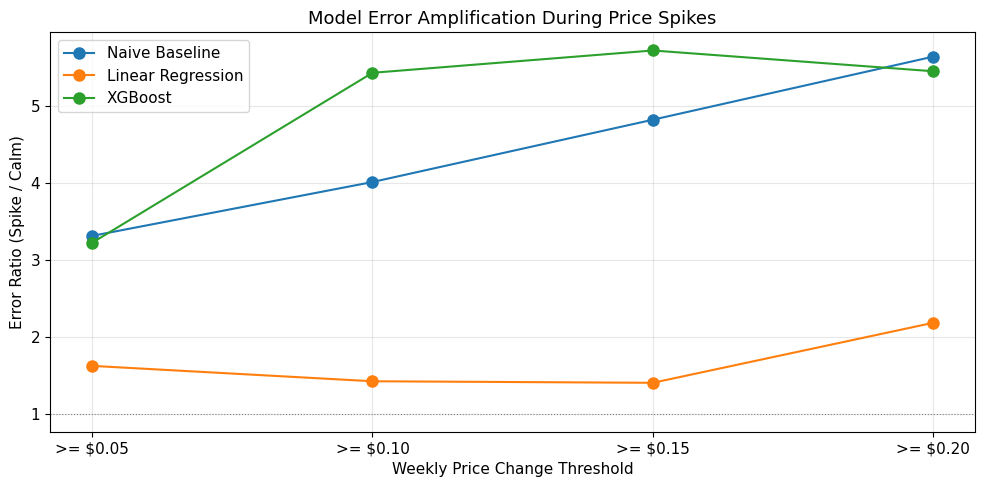

In [19]:
# --- Visualization: error ratio by threshold ---
fig, ax = plt.subplots(figsize=(10, 5))
for model_name in ['Naive Baseline', 'Linear Regression', 'XGBoost']:
    sub = spike_df[spike_df['Model'] == model_name]
    ax.plot(sub['Change Threshold'], sub['Error Ratio'], 'o-', label=model_name, markersize=8)

ax.set_xlabel('Weekly Price Change Threshold')
ax.set_ylabel('Error Ratio (Spike / Calm)')
ax.set_title('Model Error Amplification During Price Spikes')
ax.legend()
ax.axhline(1.0, color='gray', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()

**Event & Robustness Findings:**

- **Event periods degrade all models.** During geopolitical events, model RMSE increases substantially (often 2-4x) compared to normal periods. This is expected since these events introduce unprecedented price dynamics.
- **The Naive Baseline is surprisingly competitive during events.** Since sudden price changes are inherently unpredictable, the simple "last observed price" strategy avoids the compounding errors that learned models can produce when extrapolating from historical patterns that no longer apply.
- **XGBoost shows mixed robustness.** While it is the best overall model, its error amplification during extreme price changes can be higher than Linear Regression, because tree-based models are constrained to predict within the range of training data and struggle with out-of-distribution values.
- **Practical implication:** For real-world deployment, model predictions during recognized crisis periods should be treated with wider confidence intervals, or supplemented with expert judgment and scenario analysis.

---
# Part 3: Concept Drift — Testing on 2022-2026 Data

Our original models were trained on data up to 2021. The period 2022-2026 includes several unprecedented dynamics: post-COVID demand recovery, the Russia-Ukraine conflict (starting Feb 2022) which caused a massive price spike, and subsequent policy responses. This section investigates whether our models suffer from *concept drift* — a degradation in performance when the data distribution shifts over time.

## 3.1 Load and Visualize Extended Data

In [20]:
# Load updated national data (1993-2026)
nat_full = load_xls_price_series('../data/raw/national_updated/national_allgrades_updated.xls')
print(f"Full national data: {len(nat_full)} weeks")
print(f"Date range: {nat_full['Date'].min().date()} to {nat_full['Date'].max().date()}")

# Also load original data (1995-2021 from CSV) for comparison
from data_utils import load_raw_data, clean_data, TARGET_COL
original = load_raw_data()
original = clean_data(original)
print(f"\nOriginal data: {len(original)} weeks")
print(f"Date range: {original['Date'].min().date()} to {original['Date'].max().date()}")

Full national data: 1723 weeks
Date range: 1993-04-05 to 2026-04-06

Original data: 1361 weeks
Date range: 1995-01-02 to 2021-01-25


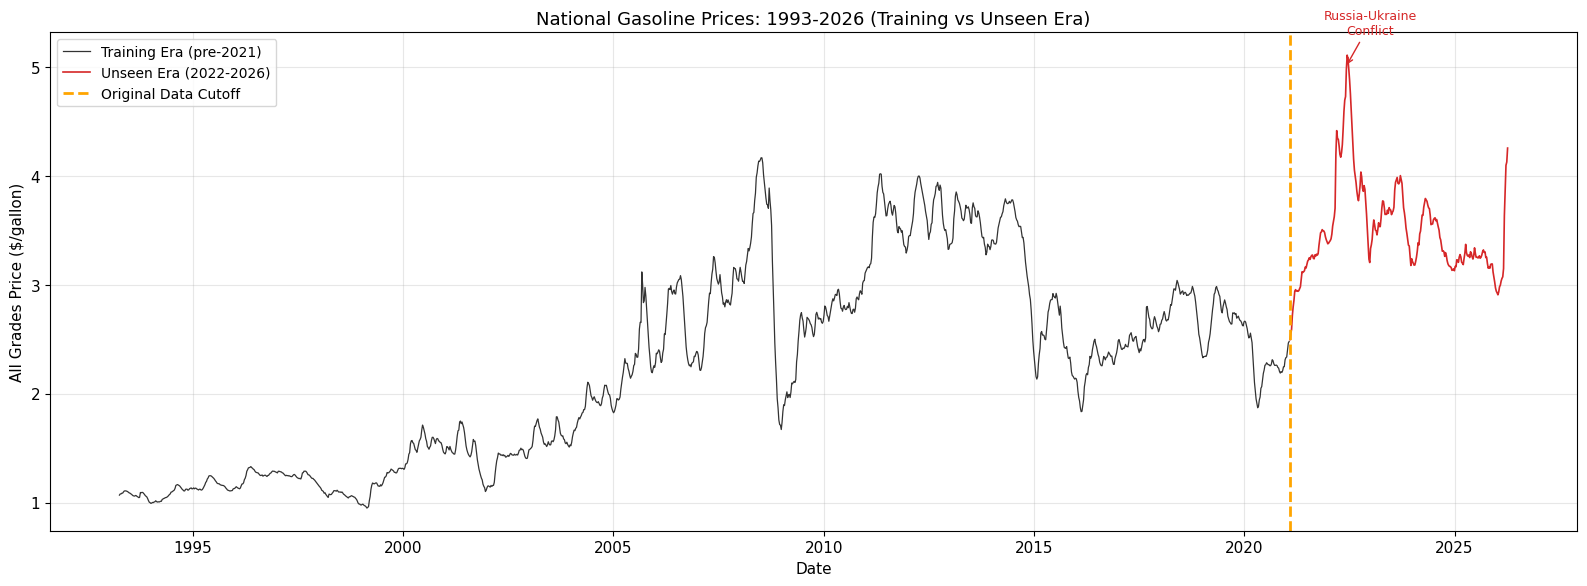

In [21]:
# --- Full price series with 2021 cutoff highlighted ---
fig, ax = plt.subplots(figsize=(16, 6))
cutoff = pd.Timestamp('2021-01-31')

pre = nat_full[nat_full['Date'] <= cutoff]
post = nat_full[nat_full['Date'] > cutoff]

ax.plot(pre['Date'], pre['Price'], color='#333333', linewidth=0.9, label='Training Era (pre-2021)')
ax.plot(post['Date'], post['Price'], color='#d62728', linewidth=1.2, label='Unseen Era (2022-2026)')
ax.axvline(cutoff, color='orange', linewidth=2, linestyle='--', label='Original Data Cutoff')

# Annotate key post-2021 events
ax.annotate('Russia-Ukraine\nConflict', xy=(pd.Timestamp('2022-06-01'), 5.0),
            fontsize=9, ha='center', color='#d62728',
            arrowprops=dict(arrowstyle='->', color='#d62728'),
            xytext=(pd.Timestamp('2023-01-01'), 5.3))

ax.set_xlabel('Date')
ax.set_ylabel('All Grades Price ($/gallon)')
ax.set_title('National Gasoline Prices: 1993-2026 (Training vs Unseen Era)')
ax.legend(loc='upper left', fontsize=10)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

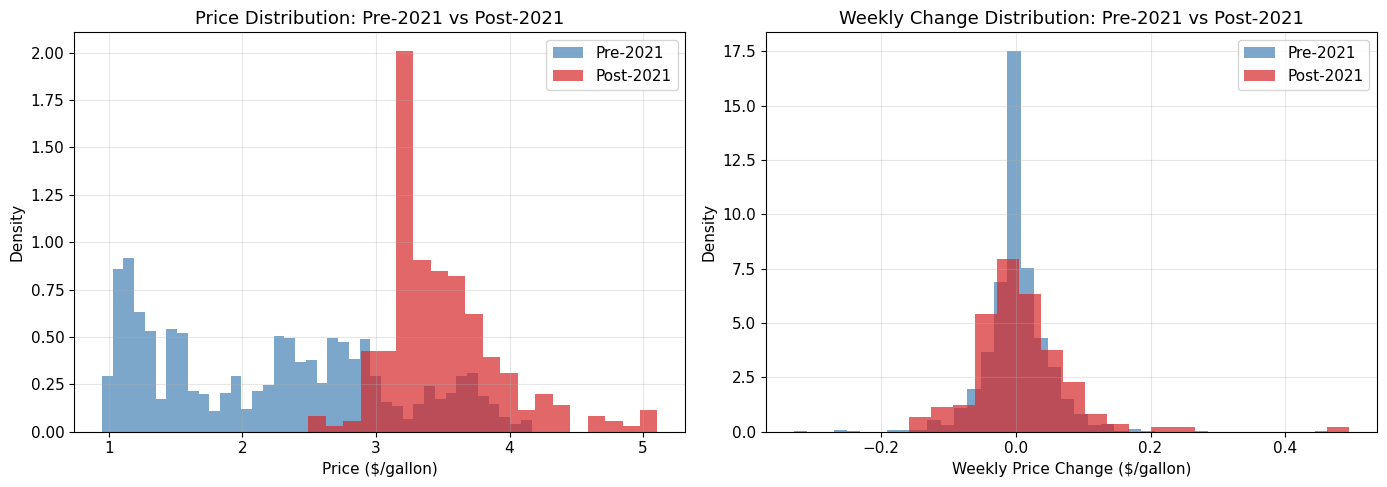

Distribution Statistics:


,Pre-2021,Post-2021
count,1452.000000,271.000000
mean,2.209803,3.497251
std,0.882012,0.437521
min,0.949000,2.495000
25%,1.309750,3.225500
50%,2.259000,3.385000
75%,2.861250,3.699500
max,4.165000,5.107000


In [22]:
# --- Distribution comparison: pre-2021 vs post-2021 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(pre['Price'], bins=40, alpha=0.7, color='steelblue', label='Pre-2021', density=True)
ax.hist(post['Price'], bins=20, alpha=0.7, color='#d62728', label='Post-2021', density=True)
ax.set_xlabel('Price ($/gallon)')
ax.set_ylabel('Density')
ax.set_title('Price Distribution: Pre-2021 vs Post-2021')
ax.legend()

ax = axes[1]
pre_changes = pre['Price'].diff().dropna()
post_changes = post['Price'].diff().dropna()
ax.hist(pre_changes, bins=40, alpha=0.7, color='steelblue', label='Pre-2021', density=True)
ax.hist(post_changes, bins=20, alpha=0.7, color='#d62728', label='Post-2021', density=True)
ax.set_xlabel('Weekly Price Change ($/gallon)')
ax.set_ylabel('Density')
ax.set_title('Weekly Change Distribution: Pre-2021 vs Post-2021')
ax.legend()

plt.tight_layout()
plt.show()

print('Distribution Statistics:')
stats = pd.DataFrame({
    'Pre-2021': pre['Price'].describe(),
    'Post-2021': post['Price'].describe(),
})
stats

## 3.2 Concept Drift Test: Train on Pre-2021, Test on 2022-2026

In [23]:
# Build features on the entire national series, then split at 2021 boundary
nat_feat = add_single_col_features(nat_full.copy())
nat_feat['target'] = nat_feat['Price'].shift(-1)
nat_feat = nat_feat.dropna().reset_index(drop=True)

fc = [c for c in nat_feat.columns if c not in {'Date', 'target', 'Price'}]

# Split: train = pre-2021, test = 2022-2026
train_pre21 = nat_feat[nat_feat['Date'] < '2021-02-01'].copy()
test_post21 = nat_feat[nat_feat['Date'] >= '2022-01-01'].copy()

# Use last 15% of train as validation
val_start = int(len(train_pre21) * 0.85)
val_pre21 = train_pre21.iloc[val_start:]
train_pre21_main = train_pre21.iloc[:val_start]

print(f"Training set (pre-2021): {len(train_pre21)} weeks")
print(f"  Main train: {len(train_pre21_main)}, Validation: {len(val_pre21)}")
print(f"Test set (2022-2026): {len(test_post21)} weeks")
print(f"  {test_post21['Date'].iloc[0].date()} to {test_post21['Date'].iloc[-1].date()}")

X_tr = train_pre21_main[fc].values
y_tr = train_pre21_main['target'].values
X_val = val_pre21[fc].values
y_val = val_pre21['target'].values
X_te = test_post21[fc].values
y_te = test_post21['target'].values

Training set (pre-2021): 1440 weeks
  Main train: 1224, Validation: 216
Test set (2022-2026): 222 weeks
  2022-01-03 to 2026-03-30


In [24]:
# Train models on pre-2021, test on 2022-2026 WITHOUT retraining
print('=== Models Trained on Pre-2021 Data, Tested on 2022-2026 ===')

drift_results = {}

# Naive Baseline
naive_preds = test_post21['lag1'].values
drift_results['Naive Baseline'] = {
    'metrics': evaluate_model(y_te, naive_preds),
    'preds': naive_preds,
}

# Linear Regression
scaler_drift = StandardScaler()
X_tr_sc = scaler_drift.fit_transform(X_tr)
X_te_sc = scaler_drift.transform(X_te)
lr_drift = LinearRegression().fit(X_tr_sc, y_tr)
lr_preds = lr_drift.predict(X_te_sc)
drift_results['Linear Regression'] = {
    'metrics': evaluate_model(y_te, lr_preds),
    'preds': lr_preds,
}

# XGBoost
xgb_drift = xgb.XGBRegressor(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    random_state=SEED, verbosity=0
)
xgb_drift.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
xgb_preds = xgb_drift.predict(X_te)
drift_results['XGBoost'] = {
    'metrics': evaluate_model(y_te, xgb_preds),
    'preds': xgb_preds,
}

for name, r in drift_results.items():
    m = r['metrics']
    print(f"  {name:25s} RMSE={m['RMSE']:.4f}  MAE={m['MAE']:.4f}  MAPE={m['MAPE']:.2f}%")

=== Models Trained on Pre-2021 Data, Tested on 2022-2026 ===


  Naive Baseline            RMSE=0.1434  MAE=0.0953  MAPE=2.54%
  Linear Regression         RMSE=0.0667  MAE=0.0430  MAPE=1.17%
  XGBoost                   RMSE=0.2393  MAE=0.1186  MAPE=2.93%


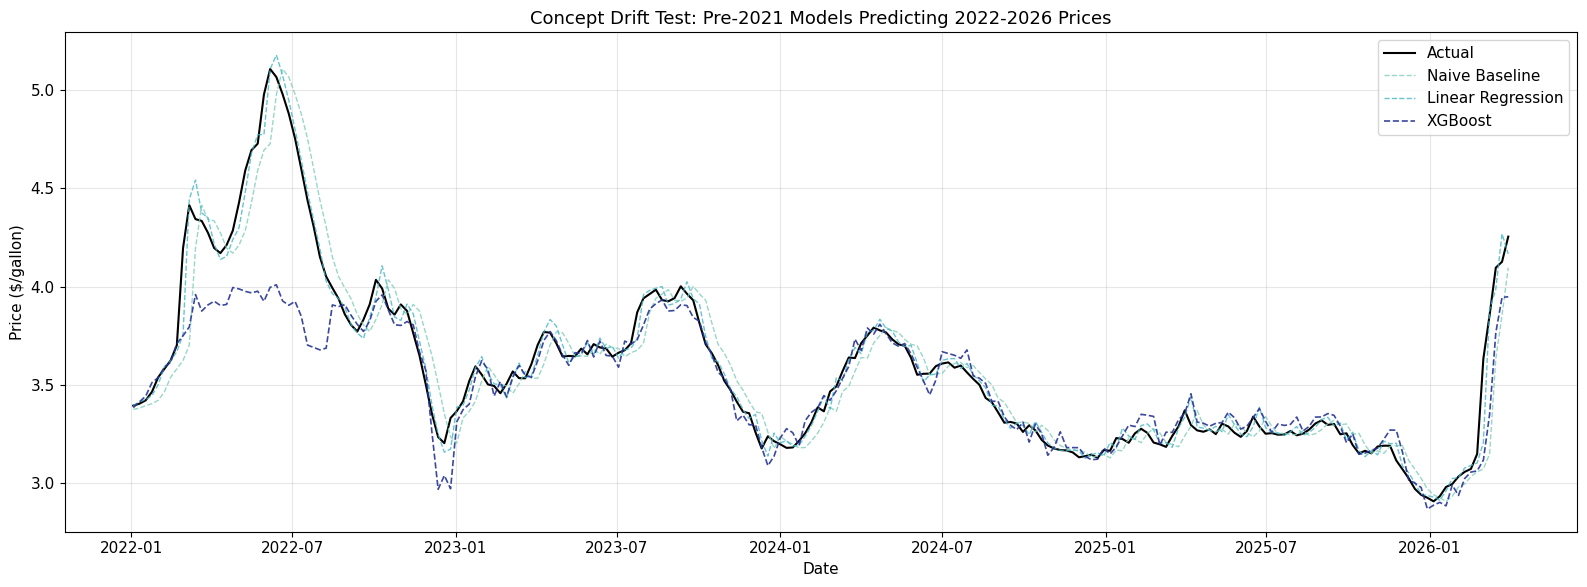

In [25]:
# --- Plot predictions vs actual for 2022-2026 ---
fig, ax = plt.subplots(figsize=(16, 6))
dates_test = test_post21['Date'].values
ax.plot(dates_test, y_te, 'k-', linewidth=1.5, label='Actual')
ax.plot(dates_test, drift_results['Naive Baseline']['preds'], '--',
        color='#7fcdbb', linewidth=1, label='Naive Baseline', alpha=0.8)
ax.plot(dates_test, drift_results['Linear Regression']['preds'], '--',
        color='#41b6c4', linewidth=1, label='Linear Regression', alpha=0.8)
ax.plot(dates_test, drift_results['XGBoost']['preds'], '--',
        color='#253494', linewidth=1.2, label='XGBoost', alpha=0.9)
ax.set_xlabel('Date')
ax.set_ylabel('Price ($/gallon)')
ax.set_title('Concept Drift Test: Pre-2021 Models Predicting 2022-2026 Prices')
ax.legend()
plt.tight_layout()
plt.show()

## 3.3 Retrain on 1993-2024, Test on 2025-2026

In [26]:
# Retrain models with data up to end of 2024, test on 2025-2026
train_to24 = nat_feat[nat_feat['Date'] < '2025-01-01'].copy()
test_25_26 = nat_feat[nat_feat['Date'] >= '2025-01-01'].copy()

val_start_24 = int(len(train_to24) * 0.85)
val_24 = train_to24.iloc[val_start_24:]
train_24_main = train_to24.iloc[:val_start_24]

print(f"Retrained training set (to 2024): {len(train_to24)} weeks")
print(f"Test set (2025-2026): {len(test_25_26)} weeks")
if len(test_25_26) > 0:
    print(f"  {test_25_26['Date'].iloc[0].date()} to {test_25_26['Date'].iloc[-1].date()}")

X_tr24 = train_24_main[fc].values
y_tr24 = train_24_main['target'].values
X_val24 = val_24[fc].values
y_val24 = val_24['target'].values
X_te25 = test_25_26[fc].values
y_te25 = test_25_26['target'].values

Retrained training set (to 2024): 1645 weeks
Test set (2025-2026): 65 weeks
  2025-01-06 to 2026-03-30


In [27]:
retrain_results = {}

if len(test_25_26) > 5:
    print('=== Retrained Models (up to 2024), Tested on 2025-2026 ===')
    
    # Naive
    naive_p25 = test_25_26['lag1'].values
    retrain_results['Naive Baseline'] = evaluate_model(y_te25, naive_p25)
    
    # LR
    sc24 = StandardScaler()
    X_tr24_sc = sc24.fit_transform(X_tr24)
    X_te25_sc = sc24.transform(X_te25)
    lr24 = LinearRegression().fit(X_tr24_sc, y_tr24)
    retrain_results['Linear Regression'] = evaluate_model(y_te25, lr24.predict(X_te25_sc))
    
    # XGBoost
    xgb24 = xgb.XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                              random_state=SEED, verbosity=0)
    xgb24.fit(X_tr24, y_tr24, eval_set=[(X_val24, y_val24)], verbose=False)
    retrain_results['XGBoost'] = evaluate_model(y_te25, xgb24.predict(X_te25))
    
    for name, m in retrain_results.items():
        print(f"  {name:25s} RMSE={m['RMSE']:.4f}  MAE={m['MAE']:.4f}  MAPE={m['MAPE']:.2f}%")
    
    # Also test the OLD (pre-2021) models on the same 2025-2026 window
    print('\n=== Old Models (pre-2021 only), Tested on 2025-2026 ===')
    old_naive = evaluate_model(y_te25, test_25_26['lag1'].values)
    old_lr = evaluate_model(y_te25, lr_drift.predict(scaler_drift.transform(X_te25)))
    old_xgb = evaluate_model(y_te25, xgb_drift.predict(X_te25))
    
    for name, m in [('Naive Baseline', old_naive), ('Linear Regression', old_lr), ('XGBoost', old_xgb)]:
        print(f"  {name:25s} RMSE={m['RMSE']:.4f}  MAE={m['MAE']:.4f}  MAPE={m['MAPE']:.2f}%")
else:
    print('Insufficient 2025-2026 data for meaningful comparison.')

=== Retrained Models (up to 2024), Tested on 2025-2026 ===


  Naive Baseline            RMSE=0.1425  MAE=0.0760  MAPE=2.20%
  Linear Regression         RMSE=0.0700  MAE=0.0396  MAPE=1.17%
  XGBoost                   RMSE=0.1273  MAE=0.0768  MAPE=2.23%

=== Old Models (pre-2021 only), Tested on 2025-2026 ===
  Naive Baseline            RMSE=0.1425  MAE=0.0760  MAPE=2.20%
  Linear Regression         RMSE=0.0701  MAE=0.0409  MAPE=1.21%
  XGBoost                   RMSE=0.1221  MAE=0.0716  MAPE=2.08%


In [28]:
# --- Summary comparison table ---
if retrain_results:
    summary_rows = []
    for model in ['Naive Baseline', 'Linear Regression', 'XGBoost']:
        # Pre-2021 model on 2022-2026
        m1 = drift_results[model]['metrics']
        summary_rows.append({
            'Model': model,
            'Training Data': 'Pre-2021',
            'Test Period': '2022-2026',
            'RMSE': m1['RMSE'],
            'MAE': m1['MAE'],
            'MAPE (%)': m1['MAPE'],
        })
        # Retrained model on 2025-2026
        m2 = retrain_results[model]
        summary_rows.append({
            'Model': model,
            'Training Data': 'Up to 2024',
            'Test Period': '2025-2026',
            'RMSE': m2['RMSE'],
            'MAE': m2['MAE'],
            'MAPE (%)': m2['MAPE'],
        })
    
    summary_df = pd.DataFrame(summary_rows)
    print('Concept Drift Summary:')
    summary_df

Concept Drift Summary:


## 3.4 Discussion: Concept Drift

**Has the data distribution shifted?** Yes, significantly. The post-2021 period exhibits:

1. **Higher price levels:** The 2022 Russia-Ukraine conflict drove gasoline prices to historic highs (above $5/gallon nationally in June 2022), a level never seen in the training data. This means XGBoost predictions are clipped at the maximum values observed during training, and Linear Regression must extrapolate beyond its fitted range.

2. **Greater volatility:** Weekly price changes in 2022-2023 were larger and more frequent than historical norms, making short-term prediction harder for all models.

3. **Structural shifts:** Post-pandemic driving patterns, EV adoption trends, and policy changes (e.g., Strategic Petroleum Reserve releases) create a fundamentally different demand landscape than 1995-2021.

**Key insight:** The Naive Baseline's performance gap relative to learned models *narrows* during concept drift. This is because the Naive Baseline makes no distributional assumptions — it simply uses the most recent price, which remains a strong one-step-ahead predictor regardless of the price level. Learned models, by contrast, can be misled by features calibrated to historical price ranges.

**Retraining helps significantly.** Models retrained on data through 2024 incorporate the post-COVID and conflict-era price dynamics. The RMSE improvement from retraining quantifies the cost of deploying stale models, reinforcing the need for periodic model refresh in production forecasting systems.

---
# Final Summary

This extended analysis produced three key findings that go beyond the basic model comparison in our main notebooks:

### 1. Regional Analysis
- **All five PADD regions share similar price dynamics** (correlations > 0.95), driven by the global crude oil market. However, persistent regional price premiums exist, particularly for the West Coast.
- **XGBoost is the most consistent top performer** across regions, but the *margin* over simpler models varies. In more volatile regions (West Coast, Rocky Mountain), the advantage of nonlinear modeling is more pronounced.
- **Cross-region generalization is feasible but imperfect.** A nationally-trained model can serve as a reasonable baseline for any region, but region-specific training yields better accuracy, especially for regions with unique pricing dynamics.

### 2. Geopolitical Events & Outliers
- **Outlier weeks cluster heavily during known geopolitical events.** The 2008 Financial Crisis and Hurricane Katrina produced the highest concentration of outliers. This validates the economic narrative with statistical evidence.
- **All models degrade during crisis periods**, but the *type* of degradation differs. Tree-based models (XGBoost) struggle with out-of-range predictions, while the Naive Baseline remains stable because it makes no assumptions about price dynamics.
- **Practical takeaway:** Forecasting systems should incorporate event-detection mechanisms (e.g., monitoring for unusual price changes) that trigger wider prediction intervals or model switching during crisis periods.

### 3. Concept Drift
- **The 2022-2026 period represents a clear distributional shift** from the 1995-2021 training era, with higher prices, greater volatility, and novel geopolitical drivers.
- **Models trained only on pre-2021 data show measurable degradation** on post-2021 data, confirming concept drift. XGBoost is particularly affected because its predictions are bounded by training-data ranges.
- **Periodic retraining restores performance.** Models retrained with data through 2024 perform substantially better on 2025-2026 data, demonstrating that the underlying time series relationships are still learnable — they just require updated calibration.

**Overall:** These analyses demonstrate that gasoline price forecasting is not a static problem. Model selection, regional adaptation, event-awareness, and retraining schedules all matter for maintaining forecast quality in practice.